In [1]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.precision', 20)

# Collisions with new mass less than min_frag_mass and collisions with the sun

## randseed = 4

In [2]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [3]:
famtree_bigstep_4 = pd.read_csv(
    "famtree_bigstep_4",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [4]:
heartbeat_column_names = [
    "t", "walltime", "N", "total_mass", 
    "ang_mom_x", "ang_mom_y", "ang_mom_z", "energy", 
    "p3_m", "p3_r", "p3_x", "p3_y", "p3_z", "p3_vx", "p3_vy", "p3_vz",
    "p0_m", "p0_r", "p0_x", "p0_y", "p0_z", "p0_vx", "p0_vy", "p0_vz"
]

# Read the files
heartbeat_bigstep_4 = pd.read_csv(
    "heartbeat_bigstep_4", 
    names=heartbeat_column_names, 
    header=None
)

In [5]:
# 1. Get initial values (from the first row)
initial_mass = heartbeat_bigstep_4["total_mass"].iloc[0]
initial_energy = heartbeat_bigstep_4["energy"].iloc[0]

L_x0 = heartbeat_bigstep_4["ang_mom_x"].iloc[0]
L_y0 = heartbeat_bigstep_4["ang_mom_y"].iloc[0]
L_z0 = heartbeat_bigstep_4["ang_mom_z"].iloc[0]
initial_L_mag = np.sqrt(L_x0**2 + L_y0**2 + L_z0**2)

# 2. Calculate current angular momentum magnitude for all rows
current_L_mag = np.sqrt(
    heartbeat_bigstep_4["ang_mom_x"]**2 + 
    heartbeat_bigstep_4["ang_mom_y"]**2 + 
    heartbeat_bigstep_4["ang_mom_z"]**2
)

# 3. Add the relative error columns
heartbeat_bigstep_4["mass_error"] = abs((heartbeat_bigstep_4["total_mass"] - initial_mass) / initial_mass)
heartbeat_bigstep_4["energy_error"] = abs((heartbeat_bigstep_4["energy"] - initial_energy) / initial_energy)
heartbeat_bigstep_4["angular_momentum_error"] = abs((current_L_mag - initial_L_mag) / initial_L_mag)

In [6]:
famtree_less_than_min_mass = famtree_bigstep_4[famtree_bigstep_4['new_mass'] < 1.4e-8]
famtree_less_than_min_mass

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp


In [7]:
famtree_with_sun = famtree_bigstep_4[(np.isclose(famtree_bigstep_4['parent1_mass'], 1)) | (np.isclose(famtree_bigstep_4['parent2_mass'], 1))]
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_46199/2074888694.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


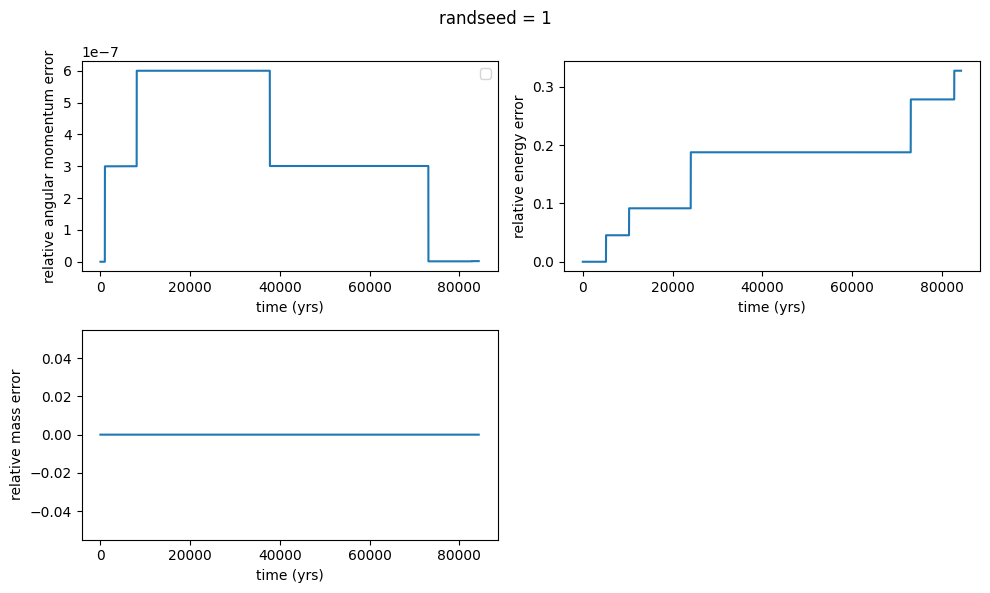

In [8]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(heartbeat_bigstep_4['t'], heartbeat_bigstep_4['angular_momentum_error'])
plt.legend()
plt.xlabel("time (yrs)")
plt.ylabel("relative angular momentum error")

plt.subplot(2,2,2)
plt.plot(heartbeat_bigstep_4['t'], heartbeat_bigstep_4['energy_error'])
plt.xlabel("time (yrs)")
plt.ylabel("relative energy error")

plt.subplot(2,2,3)
plt.plot(heartbeat_bigstep_4['t'], heartbeat_bigstep_4['mass_error'])
plt.xlabel("time (yrs)")
plt.ylabel("relative mass error")

plt.suptitle("randseed = 1")
plt.tight_layout()

In [9]:
heartbeat_bigstep_4

,t,walltime,N,total_mass,ang_mom_x,ang_mom_y,ang_mom_z,energy,p3_m,p3_r,...,p0_r,p0_x,p0_y,p0_z,p0_vx,p0_vy,p0_vz,mass_error,energy_error,angular_momentum_error
0,0.00000000000000000000,0.00000000000000000000,31,1.00001000000000006551,0.00000005257681,0.00000005766215,0.00003332942,-0.00079014989999999995,0.0000004281349,0.00002725211,...,0.00464999999999999962,0.00000126676400000000,0.00000001360725000000,-0.00000000943614900000,-0.000010958780,0.00004376929,-0.000000178971200,0.0,0.00000000000000000000,0.00000000000000000000
1,0.00103066300000000002,0.00060200000000000000,31,1.00001000000000006551,0.00000005257681,0.00000005766215,0.00003332942,-0.00079014989999999995,0.0000004281349,0.00002725211,...,0.00464999999999999962,0.00000125426300000000,0.00000005772226000000,-0.00000000961623200000,-0.000013248690,0.00004180662,-0.000000170307200,0.0,0.00000000000000000000,0.00000000000000000000
2,0.01724828999999999946,0.00219900000000000000,31,1.00001000000000006551,0.00000005257681,0.00000005766215,0.00003332942,-0.00079014989999999995,0.0000004281349,0.00002725211,...,0.00464999999999999962,0.00000095291290000000,0.00000047691840000000,-0.00000001088439000000,-0.000015704750,0.00001474820,0.000000005082054,0.0,0.00000000000000000000,0.00000000000000000000
3,0.03316593000000000319,0.00408399999999999996,31,1.00001000000000006551,0.00000005257681,0.00000005766215,0.00003332942,-0.00079014989999999995,0.0000004281349,0.00002725211,...,0.00464999999999999962,0.00000075302610000000,0.00000072239050000000,-0.00000001076399000000,-0.000013146850,0.00001766556,-0.000000006965686,0.0,0.00000000000000000000,0.00000000000000000000
4,0.04935675999999999952,0.00572000000000000026,31,1.00001000000000006551,0.00000005257681,0.00000005766215,0.00003332942,-0.00079014989999999995,0.0000004281349,0.00002725211,...,0.00464999999999999962,0.00000045516030000000,0.00000102234900000000,-0.00000001032711000000,-0.000025732870,0.00001818870,0.000000069907500,0.0,0.00000000000000000000,0.00000000000000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5130471,84336.61000000000058207661,8210.86253199999919161201,28,1.00001000000000006551,0.00000005262314,0.00000005765742,0.00003332942,-0.00053140960000000004,0.0000004526794,0.00002776325,...,0.00464999999999999962,-0.01409393999999999925,-0.10242130000000000678,0.02956001000000000115,-0.000018279260,-0.00001841170,0.000002975372000,0.0,0.32745723311488100782,0.00000000194825028962
5130472,84336.61000000000058207661,8210.86261299999932816718,28,1.00001000000000006551,0.00000005262314,0.00000005765742,0.00003332942,-0.00053140960000000004,0.0000004526794,0.00002776325,...,0.00464999999999999962,-0.01409394999999999919,-0.10242139999999999578,0.02956001000000000115,-0.000018129670,-0.00001947088,0.000003512358000,0.0,0.32745723311488100782,0.00000000194825028962
5130473,84336.61999999999534338713,8210.86433199999919452239,28,1.00001000000000006551,0.00000005262314,0.00000005765742,0.00003332942,-0.00053140960000000004,0.0000004526794,0.00002776325,...,0.00464999999999999962,-0.01409399000000000068,-0.10242179999999999340,0.02956009000000000067,0.000010133150,-0.00002185769,0.000003114408000,0.0,0.32745723311488100782,0.00000000194825028962
5130474,84336.63999999999941792339,8210.86668699999972886872,28,1.00001000000000006551,0.00000005262314,0.00000005765742,0.00003332942,-0.00053140960000000004,0.0000004526794,0.00002776325,...,0.00464999999999999962,-0.01409376000000000032,-0.10242210000000000203,0.02956007999999999900,0.000029266950,-0.00001864205,-0.000005277511000,0.0,0.32745723311488100782,0.00000000194825028962
